# NPR Deepfake Detection — Phase 1 Preprocessing Notebook — Optimized Fast Scan

This notebook prepares the **ForenSynths / Wang_CVPR2020** dataset for the NPR deepfake-detection replication.

It is designed for your current stage:

- Use **only the first dataset: ForenSynths**.
- Use the paper's 4-class ProGAN training setting: **car, cat, chair, horse**.
- Build clean CSV/JSON manifests for the next implementation/training notebook.
- Verify paths, image loading, labels, dataloaders, and optional NPR preview.

Expected Kaggle path example:

```text
/kaggle/input/datasets/chandlertimm/forensynths/Wang_CVPR2020/training/car
/kaggle/input/datasets/chandlertimm/forensynths/Wang_CVPR2020/validation/cat
/kaggle/input/datasets/chandlertimm/forensynths/Wang_CVPR2020/testing/biggan
```


## 1. Imports and Reproducibility
Run this cell first. It imports only standard Kaggle/PyTorch packages.


In [1]:

import os
import json
import random
import shutil
from io import BytesIO
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

Leave `MANUAL_DATA_ROOT = None` for automatic discovery. If Kaggle mounts the dataset differently, paste the exact folder that contains `training`, `validation`, and `testing` into `MANUAL_DATA_ROOT`.


In [2]:

# Paste the exact root only if auto-detection fails.
# This folder should directly contain: training/, validation/, testing/
MANUAL_DATA_ROOT = None

ROOT_CANDIDATES = [
    "/kaggle/input/datasets/chandlertimm/forensynths/Wang_CVPR2020",  # your example path
    "/kaggle/input/forensynths/Wang_CVPR2020",
    "/kaggle/input/forensynths/Wang_CVPR2020/",
    "/kaggle/input/wang-cvpr2020/Wang_CVPR2020",
    "/kaggle/input/chandlertimm-forensynths/Wang_CVPR2020",
]

CLASSES = ["car", "cat", "chair", "horse"]
TRAIN_SPLIT_NAME = "training"
VAL_SPLIT_NAME = "validation"
TEST_SPLIT_NAME = "testing"

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

IMG_SIZE = 256
CROP_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# Keep this False for a fast first run. Set True when you want full corruption checking.
RUN_CORRUPTION_SCAN = False
SCAN_MAX_IMAGES = None  # None = all images if RUN_CORRUPTION_SCAN=True

# Speed controls for manifest building.
# Keep False during Phase 1 if you only need train/validation preprocessing.
# The testing folder can be very large and is usually the slowest part.
BUILD_TEST_MANIFEST = False

# For a quick debug run, set this to a small number like 500.
# For the final full preprocessing run, keep it as None.
MAX_IMAGES_PER_CLASS_LABEL = None

OUTPUT_DIR = Path("/kaggle/working/npr_forensynths_preprocessed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)


Output directory: /kaggle/working/npr_forensynths_preprocessed


## 3. Find the ForenSynths / Wang_CVPR2020 Root Folder

This cell searches for the correct dataset root and prints the first levels of the folder tree.


In [3]:

def has_expected_splits(path: Path) -> bool:
    return (path / TRAIN_SPLIT_NAME).is_dir() and ((path / VAL_SPLIT_NAME).is_dir() or (path / TEST_SPLIT_NAME).is_dir())


def limited_walk_dirs(base: Path, max_depth: int = 6):
    """Yield directories under base without scanning too deeply."""
    base = base.resolve()
    if not base.exists():
        return
    for root, dirs, _ in os.walk(base):
        root_path = Path(root)
        depth = len(root_path.relative_to(base).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        yield root_path


def find_dataset_root() -> Path:
    if MANUAL_DATA_ROOT is not None:
        manual = Path(MANUAL_DATA_ROOT)
        if not manual.exists():
            raise FileNotFoundError(f"MANUAL_DATA_ROOT does not exist: {manual}")
        if not has_expected_splits(manual):
            raise FileNotFoundError(
                f"MANUAL_DATA_ROOT exists, but it does not directly contain expected split folders: {manual}"
            )
        return manual

    for candidate in ROOT_CANDIDATES:
        p = Path(candidate)
        if p.exists() and has_expected_splits(p):
            return p

    input_root = Path("/kaggle/input")
    if input_root.exists():
        for p in limited_walk_dirs(input_root, max_depth=6):
            if p.name == "Wang_CVPR2020" and has_expected_splits(p):
                return p
        for p in limited_walk_dirs(input_root, max_depth=6):
            if has_expected_splits(p):
                return p

    raise FileNotFoundError(
        "Could not find the ForenSynths/Wang_CVPR2020 root. "
        "Set MANUAL_DATA_ROOT to the folder that contains training/, validation/, and testing/."
    )


def print_tree(root: Path, max_depth: int = 2, max_items: int = 12):
    print(f"Dataset root: {root}")
    for current, dirs, files in os.walk(root):
        current_path = Path(current)
        depth = len(current_path.relative_to(root).parts)
        if depth > max_depth:
            dirs[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{current_path.name}/")
        if files and depth <= max_depth:
            shown = files[:max_items]
            for f in shown:
                print(f"{indent}  {f}")
            if len(files) > max_items:
                print(f"{indent}  ... {len(files) - max_items} more files")
        if len(dirs) > max_items:
            del dirs[max_items:]
            print(f"{indent}  ... more folders hidden")

DATA_ROOT = find_dataset_root()
print_tree(DATA_ROOT, max_depth=3, max_items=10)


Dataset root: /kaggle/input/datasets/chandlertimm/forensynths/Wang_CVPR2020
Wang_CVPR2020/
  validation/
    ... more folders hidden
    motorbike/
      1_fake/
        03092.png
        03508.png
        05261.png
        17325.png
        10874.png
        04944.png
        19838.png
        16248.png
        08484.png
        12320.png
        ... 190 more files
      0_real/
        03092.png
        03508.png
        05261.png
        17325.png
        10874.png
        04944.png
        19838.png
        16248.png
        08484.png
        12320.png
        ... 190 more files
    airplane/
      1_fake/
        03092.png
        03508.png
        05261.png
        17325.png
        10874.png
        04944.png
        19838.png
        16248.png
        08484.png
        12320.png
        ... 190 more files
      0_real/
        03092.png
        03508.png
        05261.png
        17325.png
        10874.png
        04944.png
        19838.png
        16248.png
        08484.png

## 4. Helper Functions for Label Detection and Image Collection

The dataset can have slightly different folder layouts, so this code infers labels from folder names such as `0_real`, `1_fake`, `real`, and `fake`.


In [4]:
REAL_TOKENS = {"0_real", "real", "0", "real_images"}
FAKE_TOKENS = {"1_fake", "fake", "1", "fake_images", "synthetic"}
MANIFEST_COLUMNS = ["path", "label", "label_name", "semantic_class", "source", "split"]


def label_name(label: int) -> str:
    return "real" if label == 0 else "fake" if label == 1 else "unknown"


def normalise_name(name: str) -> str:
    return name.lower().replace("-", "_").replace(" ", "_")


def label_from_dir_name(name: str) -> Optional[int]:
    clean = normalise_name(name)
    if clean in REAL_TOKENS or clean.startswith("0_real"):
        return 0
    if clean in FAKE_TOKENS or clean.startswith("1_fake"):
        return 1
    if "real" in clean and "unreal" not in clean:
        return 0
    if "fake" in clean or "synthetic" in clean:
        return 1
    return None


def infer_label_from_path(path: Path) -> Optional[int]:
    """Return 0 for real, 1 for fake, or None if no reliable label token is found."""
    for part in reversed(path.parts):
        y = label_from_dir_name(part)
        if y is not None:
            return y
    return None


def iter_image_paths_fast(folder: Path, max_images: Optional[int] = None):
    """
    Fast generator for image files. It avoids building and sorting a huge list in memory.
    This is much faster on Kaggle input datasets than Path.rglob(...)+sorted(...).
    """
    count = 0
    if not folder.exists():
        return
    for root, dirs, files in os.walk(folder):
        dirs.sort()
        files.sort()
        for fname in files:
            if Path(fname).suffix.lower() in IMG_EXTENSIONS:
                yield Path(root) / fname
                count += 1
                if max_images is not None and count >= max_images:
                    return


def direct_label_dirs(folder: Path) -> List[Tuple[Path, int]]:
    """
    Find folders whose names explicitly contain real/fake labels.
    For ForenSynths this usually catches class/0_real and class/1_fake quickly.
    """
    found = []
    if not folder.exists():
        return found

    # First check immediate children: fastest for the normal ForenSynths layout.
    for child in folder.iterdir():
        if child.is_dir():
            y = label_from_dir_name(child.name)
            if y is not None:
                found.append((child, y))

    # If immediate children did not work, search a little deeper.
    if not found:
        for root, dirs, _ in os.walk(folder):
            root_path = Path(root)
            try:
                depth = len(root_path.relative_to(folder).parts)
            except Exception:
                depth = 0
            if depth > 3:
                dirs[:] = []
                continue
            for d in dirs:
                y = label_from_dir_name(d)
                if y is not None:
                    found.append((root_path / d, y))
    return found


def empty_manifest() -> pd.DataFrame:
    return pd.DataFrame(columns=MANIFEST_COLUMNS)


def collect_from_folder(folder: Path, split: str, semantic_class: str, source: str, max_per_label: Optional[int] = None) -> pd.DataFrame:
    rows = []

    labelled_dirs = direct_label_dirs(folder)

    if labelled_dirs:
        iterator_items = labelled_dirs
        for label_dir, y in iterator_items:
            desc = f"{split}/{semantic_class}/{label_name(y)}"
            for p in tqdm(iter_image_paths_fast(label_dir, max_per_label), desc=desc, leave=False):
                rows.append({
                    "path": str(p),
                    "label": int(y),
                    "label_name": label_name(int(y)),
                    "semantic_class": semantic_class,
                    "source": source,
                    "split": split,
                })
    else:
        # Fallback for unusual layouts: scan and infer label from every path.
        desc = f"{split}/{semantic_class}/fallback-scan"
        per_label_counter = {0: 0, 1: 0}
        for p in tqdm(iter_image_paths_fast(folder, None), desc=desc, leave=False):
            y = infer_label_from_path(p)
            if y is None:
                continue
            if max_per_label is not None and per_label_counter[y] >= max_per_label:
                continue
            per_label_counter[y] += 1
            rows.append({
                "path": str(p),
                "label": int(y),
                "label_name": label_name(int(y)),
                "semantic_class": semantic_class,
                "source": source,
                "split": split,
            })

    if not rows:
        return empty_manifest()
    return pd.DataFrame(rows)


def collect_train_or_val(split_name: str, classes: List[str]) -> pd.DataFrame:
    split_dir = DATA_ROOT / split_name
    if not split_dir.exists():
        print(f"Split not found: {split_dir}")
        return empty_manifest()

    frames = []
    for cls in classes:
        class_dir = split_dir / cls
        if not class_dir.exists():
            print(f"WARNING: missing class folder: {class_dir}")
            continue
        df_cls = collect_from_folder(
            class_dir,
            split=split_name,
            semantic_class=cls,
            source="ProGAN/LSUN",
            max_per_label=MAX_IMAGES_PER_CLASS_LABEL,
        )
        print(f"{split_name}/{cls}: {len(df_cls)} images")
        frames.append(df_cls)

    frames = [f for f in frames if len(f) > 0]
    if not frames:
        return empty_manifest()
    return pd.concat(frames, ignore_index=True)


def collect_testing() -> pd.DataFrame:
    if not BUILD_TEST_MANIFEST:
        print("Skipping testing manifest because BUILD_TEST_MANIFEST=False. This avoids the slowest scan.")
        print("Set BUILD_TEST_MANIFEST=True later when you specifically need labelled test manifests.")
        return empty_manifest()

    test_dir = DATA_ROOT / TEST_SPLIT_NAME
    if not test_dir.exists():
        print(f"Testing folder not found: {test_dir}")
        return empty_manifest()

    frames = []
    subfolders = [p for p in test_dir.iterdir() if p.is_dir()]
    for sub in tqdm(sorted(subfolders), desc="testing sources"):
        df_sub = collect_from_folder(
            sub,
            split=TEST_SPLIT_NAME,
            semantic_class="test",
            source=sub.name,
            max_per_label=MAX_IMAGES_PER_CLASS_LABEL,
        )
        if len(df_sub) == 0:
            print(f"Note: no explicitly labelled real/fake images found inside testing/{sub.name}; skipped.")
        else:
            print(f"testing/{sub.name}: {len(df_sub)} images")
            frames.append(df_sub)

    if not frames:
        return empty_manifest()
    return pd.concat(frames, ignore_index=True)


## 5. Build the Manifests

This creates clean data tables for training, validation, and labelled testing samples.


In [5]:
%%time
print("Building train and validation manifests...")
print("Tip: if this is only a debug run, set MAX_IMAGES_PER_CLASS_LABEL=500 in the config cell.")

train_df = collect_train_or_val(TRAIN_SPLIT_NAME, CLASSES)
val_df = collect_train_or_val(VAL_SPLIT_NAME, CLASSES)
test_df = collect_testing()

print("\nTrain samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Labelled test samples:", len(test_df))

if len(train_df) == 0:
    raise RuntimeError(
        "No labelled training images were found. Check DATA_ROOT and the folder names under training/. "
        "Expected labelled subfolders such as 0_real and 1_fake inside car/cat/chair/horse."
    )

print("\nTrain label counts:")
print(train_df.groupby(["semantic_class", "label_name"]).size().unstack(fill_value=0))

if len(val_df) > 0:
    print("\nValidation label counts:")
    print(val_df.groupby(["semantic_class", "label_name"]).size().unstack(fill_value=0))
else:
    print("\nNo official validation manifest was found. The next cell can create a validation split from training if needed.")

if len(test_df) > 0:
    print("\nTest label counts by source:")
    print(test_df.groupby(["source", "label_name"]).size().unstack(fill_value=0).head(20))
else:
    print("\nNo labelled test manifest built in this run.")


Building train and validation manifests...
Tip: if this is only a debug run, set MAX_IMAGES_PER_CLASS_LABEL=500 in the config cell.


training/car/fake: 0it [00:00, ?it/s]

training/car/real: 0it [00:00, ?it/s]

training/car: 36006 images


training/cat/fake: 0it [00:00, ?it/s]

...

validation/chair/real: 0it [00:00, ?it/s]

validation/chair: 400 images


validation/horse/fake: 0it [00:00, ?it/s]

validation/horse/real: 0it [00:00, ?it/s]

validation/horse: 400 images
Skipping testing manifest because BUILD_TEST_MANIFEST=False. This avoids the slowest scan.
Set BUILD_TEST_MANIFEST=True later when you specifically need labelled test manifests.

Train samples: 144024
Validation samples: 1600
Labelled test samples: 0

Train label counts:
label_name       fake   real
semantic_class              
car             18003  18003
cat             18003  18003
chair           18003  18003
horse           18003  18003

Validation label counts:
label_name      fake  real
semantic_class            
car              200   200
cat              200   200
chair            200   200
horse            200   200

No labelled test manifest built in this run.
CPU times: user 2.87 s, sys: 2.42 s, total: 5.29 s
Wall time: 2min 30s


## 6. Optional Fallback: Create Validation Split from Training

If the official validation folder is missing or has no labelled images, this cell makes an 80/20 stratified split from the training manifest.


In [6]:

if len(val_df) == 0:
    from sklearn.model_selection import train_test_split

    stratify_cols = train_df["semantic_class"].astype(str) + "_" + train_df["label"].astype(str)
    train_df, val_df = train_test_split(
        train_df,
        test_size=0.20,
        random_state=SEED,
        stratify=stratify_cols,
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    train_df["split"] = "training_generated_split"
    val_df["split"] = "validation_generated_split"
    print("Created validation split from training data.")

print("Final train samples:", len(train_df))
print("Final validation samples:", len(val_df))


Final train samples: 144024
Final validation samples: 1600


## 7. Optional Corrupted Image Scan

By default this is fast and marks everything as valid. Set `RUN_CORRUPTION_SCAN = True` in the configuration cell for a full image verification scan.


In [7]:

def scan_corrupted(df: pd.DataFrame, name: str, max_images: Optional[int] = None) -> Tuple[pd.DataFrame, List[str]]:
    if len(df) == 0:
        return df.copy(), []

    df_out = df.copy()
    df_out["is_valid"] = True
    corrupted = []

    indices = list(df_out.index)
    if max_images is not None:
        indices = indices[:max_images]

    for idx in tqdm(indices, desc=f"Checking {name}"):
        path = df_out.loc[idx, "path"]
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception:
            df_out.loc[idx, "is_valid"] = False
            corrupted.append(path)

    df_out = df_out[df_out["is_valid"]].reset_index(drop=True)
    return df_out, corrupted

if RUN_CORRUPTION_SCAN:
    train_df, bad_train = scan_corrupted(train_df, "train", SCAN_MAX_IMAGES)
    val_df, bad_val = scan_corrupted(val_df, "validation", SCAN_MAX_IMAGES)
    test_df, bad_test = scan_corrupted(test_df, "test", SCAN_MAX_IMAGES)
    corrupted_paths = bad_train + bad_val + bad_test
else:
    train_df = train_df.copy(); train_df["is_valid"] = True
    val_df = val_df.copy(); val_df["is_valid"] = True
    test_df = test_df.copy(); test_df["is_valid"] = True
    corrupted_paths = []

print("Corrupted images found:", len(corrupted_paths))
print("Train after scan:", len(train_df))
print("Validation after scan:", len(val_df))
print("Test after scan:", len(test_df))


Corrupted images found: 0
Train after scan: 144024
Validation after scan: 1600
Test after scan: 0


## 8. Save Manifests and Configuration

These files are the main output of preprocessing. The next notebook can load them directly instead of rescanning the dataset.


In [8]:

train_csv = OUTPUT_DIR / "forensynths_train_manifest.csv"
val_csv = OUTPUT_DIR / "forensynths_val_manifest.csv"
test_csv = OUTPUT_DIR / "forensynths_test_manifest.csv"
config_json = OUTPUT_DIR / "preprocessing_config.json"
corrupted_txt = OUTPUT_DIR / "corrupted_paths.txt"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

config = {
    "dataset_root": str(DATA_ROOT),
    "classes": CLASSES,
    "train_split_name": TRAIN_SPLIT_NAME,
    "validation_split_name": VAL_SPLIT_NAME,
    "test_split_name": TEST_SPLIT_NAME,
    "img_size": IMG_SIZE,
    "crop_size": CROP_SIZE,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "train_samples": int(len(train_df)),
    "validation_samples": int(len(val_df)),
    "test_samples": int(len(test_df)),
    "corrupted_count": int(len(corrupted_paths)),
    "label_meaning": {"0": "real", "1": "fake"},
}
with open(config_json, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

with open(corrupted_txt, "w", encoding="utf-8") as f:
    for p in corrupted_paths:
        f.write(str(p) + "\n")

print("Saved:")
print("-", train_csv)
print("-", val_csv)
print("-", test_csv)
print("-", config_json)
print("-", corrupted_txt)


Saved:
- /kaggle/working/npr_forensynths_preprocessed/forensynths_train_manifest.csv
- /kaggle/working/npr_forensynths_preprocessed/forensynths_val_manifest.csv
- /kaggle/working/npr_forensynths_preprocessed/forensynths_test_manifest.csv
- /kaggle/working/npr_forensynths_preprocessed/preprocessing_config.json
- /kaggle/working/npr_forensynths_preprocessed/corrupted_paths.txt


## 9. Visual Check: Raw Real/Fake Samples

This helps confirm that labels and paths are correct before training.


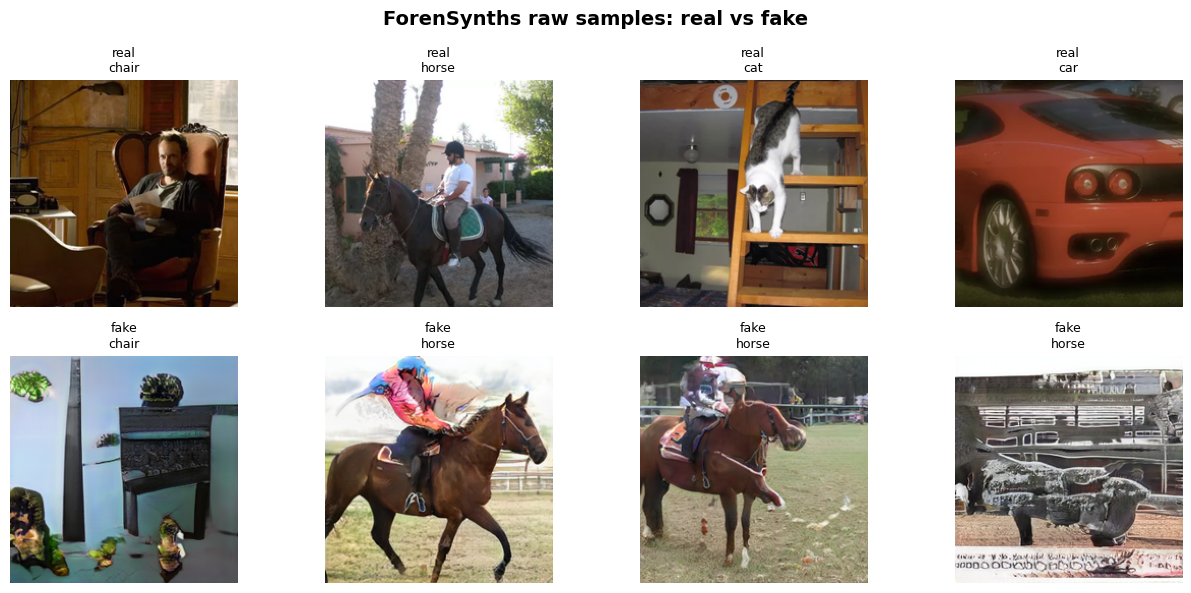

Saved: /kaggle/working/npr_forensynths_preprocessed/raw_real_fake_samples.png


In [9]:

def show_raw_samples(df: pd.DataFrame, save_path: Path, samples_per_label: int = 4):
    if len(df) == 0:
        print("No samples to visualize.")
        return

    fig, axes = plt.subplots(2, samples_per_label, figsize=(3.2 * samples_per_label, 6))
    fig.suptitle("ForenSynths raw samples: real vs fake", fontsize=14, fontweight="bold")

    for row, label in enumerate([0, 1]):
        subset = df[df["label"] == label]
        if len(subset) == 0:
            for col in range(samples_per_label):
                axes[row, col].axis("off")
            continue
        chosen = subset.sample(n=min(samples_per_label, len(subset)), random_state=SEED + label)
        for col in range(samples_per_label):
            ax = axes[row, col]
            ax.axis("off")
            if col >= len(chosen):
                continue
            path = chosen.iloc[col]["path"]
            img = Image.open(path).convert("RGB").resize((224, 224))
            ax.imshow(img)
            ax.set_title(f"{label_name(label)}\n{chosen.iloc[col]['semantic_class']}", fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

show_raw_samples(train_df, OUTPUT_DIR / "raw_real_fake_samples.png", samples_per_label=4)


## 10. JPEG Compression Helper

The training notebook can use this augmentation to improve robustness. This cell only defines and visualizes it.


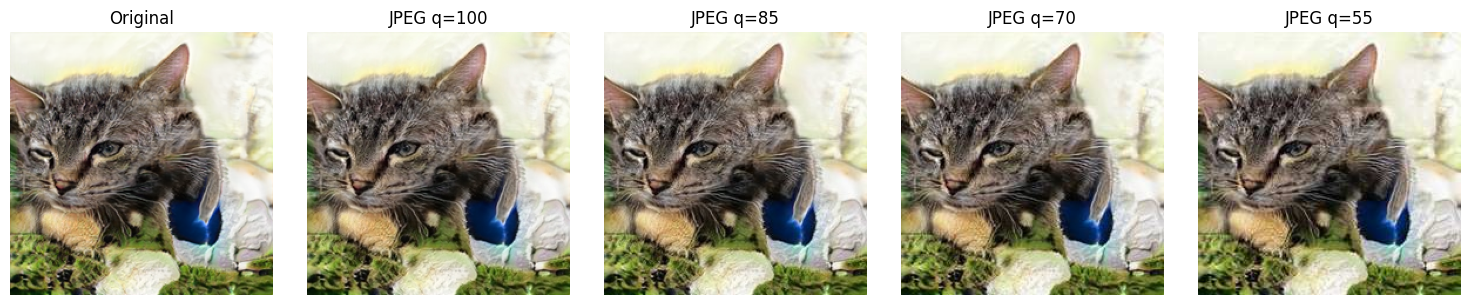

Saved: /kaggle/working/npr_forensynths_preprocessed/jpeg_compression_preview.png


In [10]:

def apply_jpeg_compression(img: Image.Image, quality: int) -> Image.Image:
    quality = int(max(1, min(100, quality)))
    buffer = BytesIO()
    img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")

# Visualize JPEG compression on one sample.
if len(train_df) > 0:
    sample_path = train_df.sample(n=1, random_state=SEED).iloc[0]["path"]
    original = Image.open(sample_path).convert("RGB").resize((224, 224))
    qualities = [100, 85, 70, 55]

    fig, axes = plt.subplots(1, len(qualities) + 1, figsize=(15, 3))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i, q in enumerate(qualities, start=1):
        compressed = apply_jpeg_compression(original, q)
        axes[i].imshow(compressed)
        axes[i].set_title(f"JPEG q={q}")
        axes[i].axis("off")

    jpeg_path = OUTPUT_DIR / "jpeg_compression_preview.png"
    plt.tight_layout()
    plt.savefig(jpeg_path, dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved:", jpeg_path)


## 11. PyTorch Dataset and DataLoaders

This prepares tensors with ImageNet normalization: `[batch, 3, 224, 224]`.


In [11]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def build_transform(split: str, normalize: bool = True):
    ops = []
    if split == "train":
        ops += [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomCrop(CROP_SIZE),
            transforms.RandomHorizontalFlip(),
        ]
    else:
        ops += [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.CenterCrop(CROP_SIZE),
        ]
    ops.append(transforms.ToTensor())
    if normalize:
        ops.append(transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD))
    return transforms.Compose(ops)


class ForenSynthsManifestDataset(Dataset):
    def __init__(
        self,
        manifest_df: pd.DataFrame,
        split: str,
        jpeg_aug: bool = False,
        jpeg_quality_range: Tuple[int, int] = (65, 100),
        normalize: bool = True,
    ):
        self.df = manifest_df.reset_index(drop=True).copy()
        self.split = split
        self.jpeg_aug = jpeg_aug and split == "train"
        self.jpeg_quality_range = jpeg_quality_range
        self.transform = build_transform(split, normalize=normalize)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        label = int(row["label"])
        img = Image.open(path).convert("RGB")

        if self.jpeg_aug:
            q = random.randint(self.jpeg_quality_range[0], self.jpeg_quality_range[1])
            img = apply_jpeg_compression(img, q)

        tensor = self.transform(img)
        return tensor, torch.tensor(label, dtype=torch.long)

train_dataset = ForenSynthsManifestDataset(train_df, split="train", jpeg_aug=True)
val_dataset = ForenSynthsManifestDataset(val_df, split="val", jpeg_aug=False)

def make_loader(dataset, shuffle: bool):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

train_loader = make_loader(train_dataset, shuffle=True)
val_loader = make_loader(val_dataset, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))


Train batches: 4501
Validation batches: 50


## 12. DataLoader Sanity Check

This catches most preprocessing mistakes before training starts.


In [12]:

imgs, labels = next(iter(train_loader))

print("Image tensor shape:", tuple(imgs.shape))
print("Label tensor shape:", tuple(labels.shape))
print("Image dtype:", imgs.dtype)
print("Label dtype:", labels.dtype)
print("Pixel min:", float(imgs.min()))
print("Pixel max:", float(imgs.max()))
print("Labels present in batch:", sorted(labels.unique().tolist()))
print("Real in batch:", int((labels == 0).sum()))
print("Fake in batch:", int((labels == 1).sum()))

assert imgs.ndim == 4, "Images must be a 4D batch tensor"
assert imgs.shape[1:] == (3, CROP_SIZE, CROP_SIZE), f"Expected [B, 3, {CROP_SIZE}, {CROP_SIZE}], got {tuple(imgs.shape)}"
assert imgs.dtype == torch.float32, "Images must be float32"
assert labels.dtype == torch.long, "Labels must be torch.long"
assert set(labels.unique().tolist()).issubset({0, 1}), "Labels must be 0/1"

print("All sanity checks passed.")


Image tensor shape: (32, 3, 224, 224)
Label tensor shape: (32,)
Image dtype: torch.float32
Label dtype: torch.int64
Pixel min: -2.1179039478302
Pixel max: 2.640000104904175
Labels present in batch: [0, 1]
Real in batch: 15
Fake in batch: 17
All sanity checks passed.


## 13. Visual Check: Preprocessed Batch

The images are denormalized only for display.


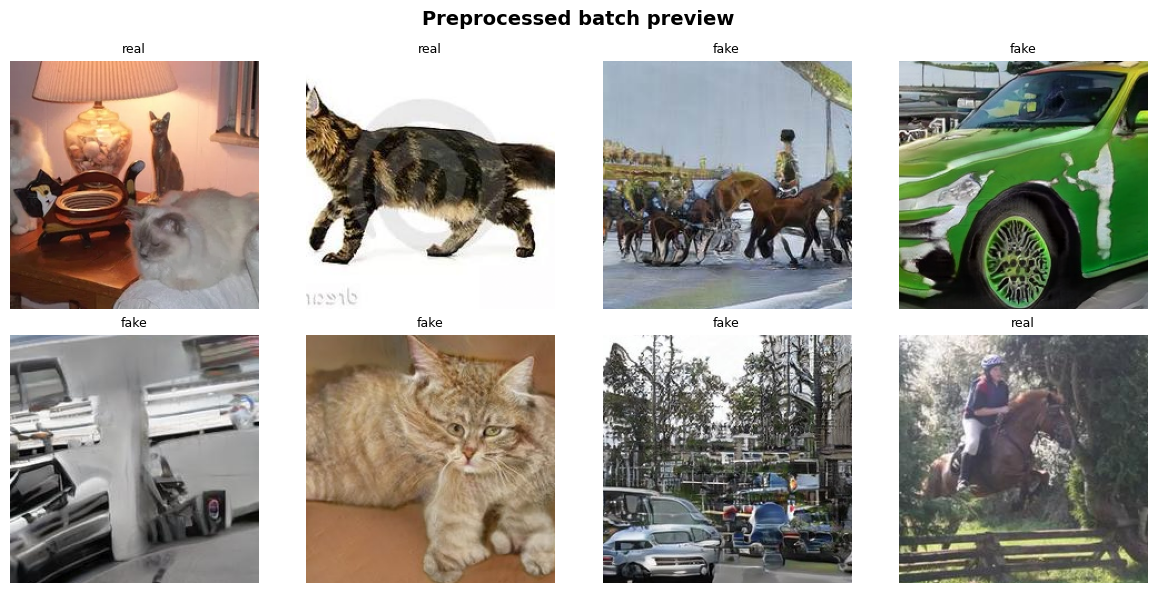

Saved: /kaggle/working/npr_forensynths_preprocessed/preprocessed_batch_preview.png


In [13]:

def denormalize_tensor(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (x.cpu() * std + mean).clamp(0, 1)

num_show = min(8, imgs.shape[0])
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Preprocessed batch preview", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    ax.axis("off")
    if i >= num_show:
        continue
    img_display = denormalize_tensor(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img_display)
    ax.set_title(label_name(int(labels[i])), fontsize=9)

batch_preview_path = OUTPUT_DIR / "preprocessed_batch_preview.png"
plt.tight_layout()
plt.savefig(batch_preview_path, dpi=120, bbox_inches="tight")
plt.show()
print("Saved:", batch_preview_path)


## 14. NPR Transform Preview

The paper's NPR representation uses local neighbouring-pixel subtraction. This cell creates a preview only; the next notebook can use the same function inside the model/training pipeline.


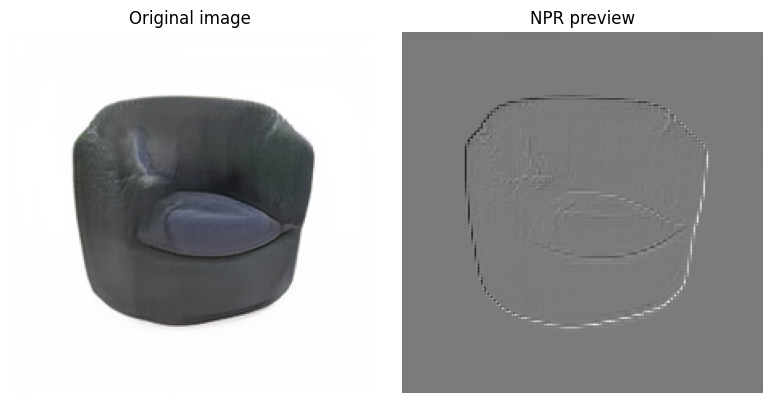

Saved: /kaggle/working/npr_forensynths_preprocessed/npr_preview.png


In [14]:

def compute_npr_tensor(x: torch.Tensor, block_size: int = 2) -> torch.Tensor:
    """
    Compute NPR using top-left pixel subtraction in each 2x2 block.
    Input:  torch tensor [C, H, W] in [0, 1]
    Output: torch tensor [C, H, W], same spatial size if H/W are even.
    """
    if x.ndim != 3:
        raise ValueError("Expected tensor shape [C, H, W]")
    c, h, w = x.shape
    h_even = h - (h % block_size)
    w_even = w - (w % block_size)
    x = x[:, :h_even, :w_even]

    out = torch.zeros_like(x)
    ref = x[:, 0::block_size, 0::block_size]

    for dy in range(block_size):
        for dx in range(block_size):
            out[:, dy::block_size, dx::block_size] = x[:, dy::block_size, dx::block_size] - ref
    return out


def normalize_for_display(x: torch.Tensor) -> torch.Tensor:
    x = x.detach().cpu()
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

# Show original vs NPR map for one sample.
sample_path = train_df.sample(n=1, random_state=SEED + 7).iloc[0]["path"]
img_pil = Image.open(sample_path).convert("RGB").resize((CROP_SIZE, CROP_SIZE))
img_tensor = transforms.ToTensor()(img_pil)
npr_tensor = compute_npr_tensor(img_tensor, block_size=2)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_tensor.permute(1, 2, 0).numpy())
axes[0].set_title("Original image")
axes[0].axis("off")
axes[1].imshow(normalize_for_display(npr_tensor).permute(1, 2, 0).numpy())
axes[1].set_title("NPR preview")
axes[1].axis("off")

npr_preview_path = OUTPUT_DIR / "npr_preview.png"
plt.tight_layout()
plt.savefig(npr_preview_path, dpi=120, bbox_inches="tight")
plt.show()
print("Saved:", npr_preview_path)


## 15. Dataset Summary Tables

Use this output in your Phase 1 documentation.


In [15]:

summary_rows = []
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    if len(df) == 0:
        summary_rows.append({"split": name, "total": 0, "real": 0, "fake": 0})
        continue
    summary_rows.append({
        "split": name,
        "total": int(len(df)),
        "real": int((df["label"] == 0).sum()),
        "fake": int((df["label"] == 1).sum()),
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

summary_csv = OUTPUT_DIR / "dataset_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv)


     split  total  real  fake
     train 144024 72012 72012
validation   1600   800   800
      test      0     0     0
Saved: /kaggle/working/npr_forensynths_preprocessed/dataset_summary.csv


## 16. Package Preprocessing Outputs

This creates a ZIP file containing the manifests, config, and preview images.


In [16]:

zip_base = Path("/kaggle/working/npr_forensynths_preprocessed")
zip_path = shutil.make_archive(str(zip_base), "zip", OUTPUT_DIR)
print("Created ZIP:", zip_path)

try:
    from IPython.display import FileLink, display
    display(FileLink(zip_path))
except Exception:
    pass


Created ZIP: /kaggle/working/npr_forensynths_preprocessed.zip


/kaggle/working/npr_forensynths_preprocessed.zip

## Phase 1 Complete

You are now ready for **Phase 2: Full implementation + training**.

Outputs created in `/kaggle/working/npr_forensynths_preprocessed/`:

- `forensynths_train_manifest.csv`
- `forensynths_val_manifest.csv`
- `forensynths_test_manifest.csv`
- `preprocessing_config.json`
- `dataset_summary.csv`
- Preview images for raw samples, JPEG compression, batch tensors, and NPR.
